# Shopping Behavior Analysis

This notebook explores customer shopping behavior using pandas and matplotlib.  
The goal is to answer business questions about revenue, age groups, seasons, promo codes, product combinations, previous purchases, and payment methods.

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/raw/shopping.csv')

df.head()

,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,3475,NaN,Male,Jacket,30.904467,Maine,M,Burnt orange,Fall,4.0,Standard,No,0,Credit Card,NaN
1,3698,21.0,Female,Backpack,31.588259,NaN,L,Turquoise,Winter,2.0,Express,No,1,Credit Card,Monthly
2,2756,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,4.0,Standard,No,0,Credit Card,NaN
3,3340,NaN,Male,Pajamas,33.918834,Nebraska,M,Black,Winter,NaN,Standard,No,2,Credit Card,Bi-Weekly
4,3391,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,NaN,Standard,No,0,Credit Card,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3510 non-null   float64
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Purchase Amount (USD)   3900 non-null   float64
 5   Location                3510 non-null   str    
 6   Size                    3900 non-null   str    
 7   Color                   3900 non-null   str    
 8   Season                  3900 non-null   str    
 9   Review Rating           1431 non-null   float64
 10  Shipping Type           3900 non-null   str    
 11  Promo Code Used         3900 non-null   str    
 12  Previous Purchases      3900 non-null   int64  
 13  Payment Method          3900 non-null   str    
 14  Frequency of Purchases  1560 non-null   str    
dty

In [4]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3510.000000,3900.000000,1431.000000,3900.000000
mean,1950.500000,34.256695,38.708329,3.904962,5.841538
std,1125.977353,10.616340,11.504923,1.105952,5.843695
min,1.000000,18.000000,11.392520,1.000000,0.000000
25%,975.750000,26.000000,29.332617,4.000000,1.000000
50%,1950.500000,33.000000,36.953004,4.000000,4.000000
75%,2925.250000,41.000000,48.739596,5.000000,9.000000
max,3900.000000,75.000000,69.567481,5.000000,20.000000


In [5]:
df.isna().sum()

Customer ID                  0
Age                        390
Gender                       0
Item Purchased               0
Purchase Amount (USD)        0
Location                   390
Size                         0
Color                        0
Season                       0
Review Rating             2469
Shipping Type                0
Promo Code Used              0
Previous Purchases           0
Payment Method               0
Frequency of Purchases    2340
dtype: int64

## Initial Data Check

The dataset was loaded successfully. I reviewed the first few rows, checked the column names and data types, and looked for missing values before starting the analysis.

# Question 1: Which age groups generate the highest total purchase revenue, and how does their average purchase amount compare?

In [6]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

age_analysis = (
    df.groupby('Age Group')['Purchase Amount (USD)']
    .agg(['sum', 'mean', 'count'])
    .sort_values(by='sum', ascending=False)
)

age_analysis

,sum,mean,count
Age Group,,,
26-35,47692.014560,38.679655,1233
36-45,35582.641605,38.761047,918
18-25,28329.817354,38.543969,735
46-55,15785.002430,38.975315,405
56-65,4440.500598,38.613049,115
65+,855.850879,40.754804,21


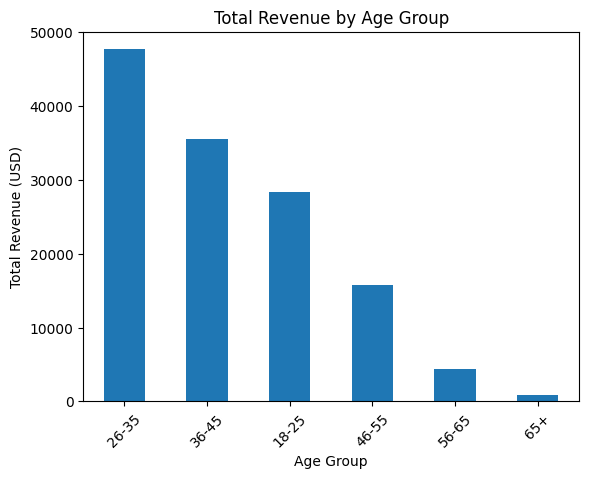

In [7]:
age_analysis['sum'].plot(kind='bar')

plt.title('Total Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45)

plt.show()

### Interpretation

The 26–35 age group generated the highest total purchase revenue, followed by the 36–45 group. Although the older age groups made fewer purchases overall, some still had relatively high average purchase amounts. This suggests that total revenue is influenced by both customer spending and purchase frequency.

# Question 2: How does purchase behavior vary by season across different U.S. locations?

In [8]:
season_location = pd.pivot_table(
    df,
    values='Purchase Amount (USD)',
    index='Location',
    columns='Season',
    aggfunc='mean'
)

season_location.head(10)

Season,Fall,Spring,Summer,Winter
Location,,,,
Alabama,37.182493,38.114163,37.311799,34.878183
Alaska,34.391545,33.259732,32.896090,41.655409
Arizona,36.699627,35.051002,37.009455,36.895387
Arkansas,41.088430,37.592506,39.834683,39.137534
California,34.942423,40.229361,37.666720,39.993398
Colorado,36.962685,35.368074,40.762249,36.120605
Connecticut,33.754902,38.743858,37.521371,34.162248
Delaware,44.208614,38.399397,38.991300,36.096087
Florida,42.025802,39.293527,42.271944,39.739051


### Interpretation

The pivot table shows how average purchase amounts vary across seasons and locations. Some states show stronger spending during specific seasons, which may reflect regional shopping habits, weather differences, or seasonal demand patterns.

# Question 3: Do customers who use promo codes spend more or less per transaction compared to those who don’t?

In [9]:
promo_analysis = (
    df.groupby('Promo Code Used')['Purchase Amount (USD)']
    .agg(['mean', 'count']))

promo_analysis

,mean,count
Promo Code Used,,
No,30.172085,2223
Yes,50.023814,1677


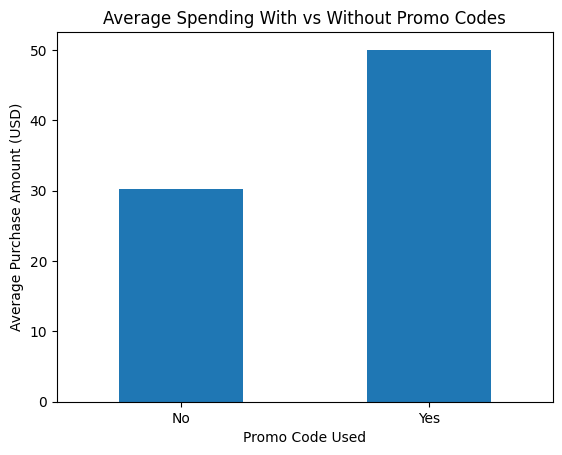

In [10]:
promo_analysis['mean'].plot(kind='bar')

plt.title('Average Spending With vs Without Promo Codes')
plt.xlabel('Promo Code Used')
plt.ylabel('Average Purchase Amount (USD)')
plt.xticks(rotation=0)

plt.show()

### Interpretation

Customers who used promo codes spent more on average per purchase than customers who did not use promo codes. This suggests that discounts or promotions may encourage customers to spend more during a transaction.

# Question 4: Which combinations of item type, size, and color are most frequently purchased together?

In [12]:
combo_analysis = (
    df.groupby(['Item Purchased', 'Size', 'Color'])
    .size()
    .reset_index(name='Purchase Count')
    .sort_values(by='Purchase Count', ascending=False)
)

combo_analysis.head(10)

,Item Purchased,Size,Color,Purchase Count
249,Handbag,M,Lavender,21
694,Socks,M,Ruby Red,19
633,Shorts,M,Lavender,19
530,Running Shoes,M,Lavender,18
860,T-shirt,M,Turquoise,18
857,T-shirt,M,Periwinkle,18
638,Shorts,M,Periwinkle,18
741,Sunglasses,M,Pale peach,17
846,T-shirt,M,Baby blue,17
524,Running Shoes,M,Baby blue,17


### Interpretation

Some item, size, and color combinations appeared much more frequently than others. Medium-sized products were especially common among the top combinations. This information could help businesses understand customer preferences and improve inventory planning.

# Final Conclusion

This analysis explored customer shopping behavior using pandas and matplotlib. The project examined revenue by age group, seasonal shopping patterns, promo code usage, and common product combinations.

The analysis showed that different customer groups and shopping behaviors can strongly affect purchase trends. Using pandas operations like groupby(), pivot tables, filtering, and data visualization helped turn raw data into useful business insights.